In [1]:
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)
print(image.height, image.width)  # [480, 640]

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base', device_map="auto")
patch_size = model.config.patch_size

inputs = processor(images=image, return_tensors="pt").to(model.device)
print(inputs.pixel_values.shape)  # [1, 3, 224, 224]
batch_size, rgb, img_height, img_width = inputs.pixel_values.shape
num_patches_height, num_patches_width = img_height // patch_size, img_width // patch_size
num_patches_flat = num_patches_height * num_patches_width

outputs = model(**inputs)
last_hidden_states = outputs[0]
print(last_hidden_states.shape)  # [1, 1 + 256, 768]
assert last_hidden_states.shape == (batch_size, 1 + num_patches_flat, model.config.hidden_size)

cls_token = last_hidden_states[:, 0, :]
patch_features = last_hidden_states[:, 1:, :].unflatten(1, (num_patches_height, num_patches_width))

480 640


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

torch.Size([1, 3, 224, 224])
torch.Size([1, 257, 768])


In [9]:
model.config

Dinov2Config {
  "apply_layernorm": true,
  "architectures": [
    "Dinov2Model"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 518,
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 14,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12"
  ],
  "transformers_version": "5.13.1",
  "use_mask_token": true,
  "use_swiglu_ffn": false
}

In [6]:
outputs['last_hidden_state'].shape

torch.Size([1, 257, 768])

In [2]:
import h5py, io, numpy as np, decord

f = h5py.File('datasets/uniform_motion_30K.hdf5', 'r')

shard, i = '00000', 0
pos    = f[f'position_streams/{shard}'][i]           # (32, 2)
init   = f[f'init_streams/{shard}'][i]               # (2,)
mp4    = f[f'video_streams/{shard}'][i].tobytes()    # raw MP4 bytes
frames = decord.VideoReader(io.BytesIO(mp4))[:].asnumpy()  # (32, 256, 256, 3) uint8

# global index 0..29999 -> (shard, row)
def get(idx):
    s, r = divmod(idx, 1000)
    k = f'{s:05d}'
    return (decord.VideoReader(io.BytesIO(f[f'video_streams/{k}'][r].tobytes()))[:].asnumpy(),
            f[f'position_streams/{k}'][r])


In [ ]:
!

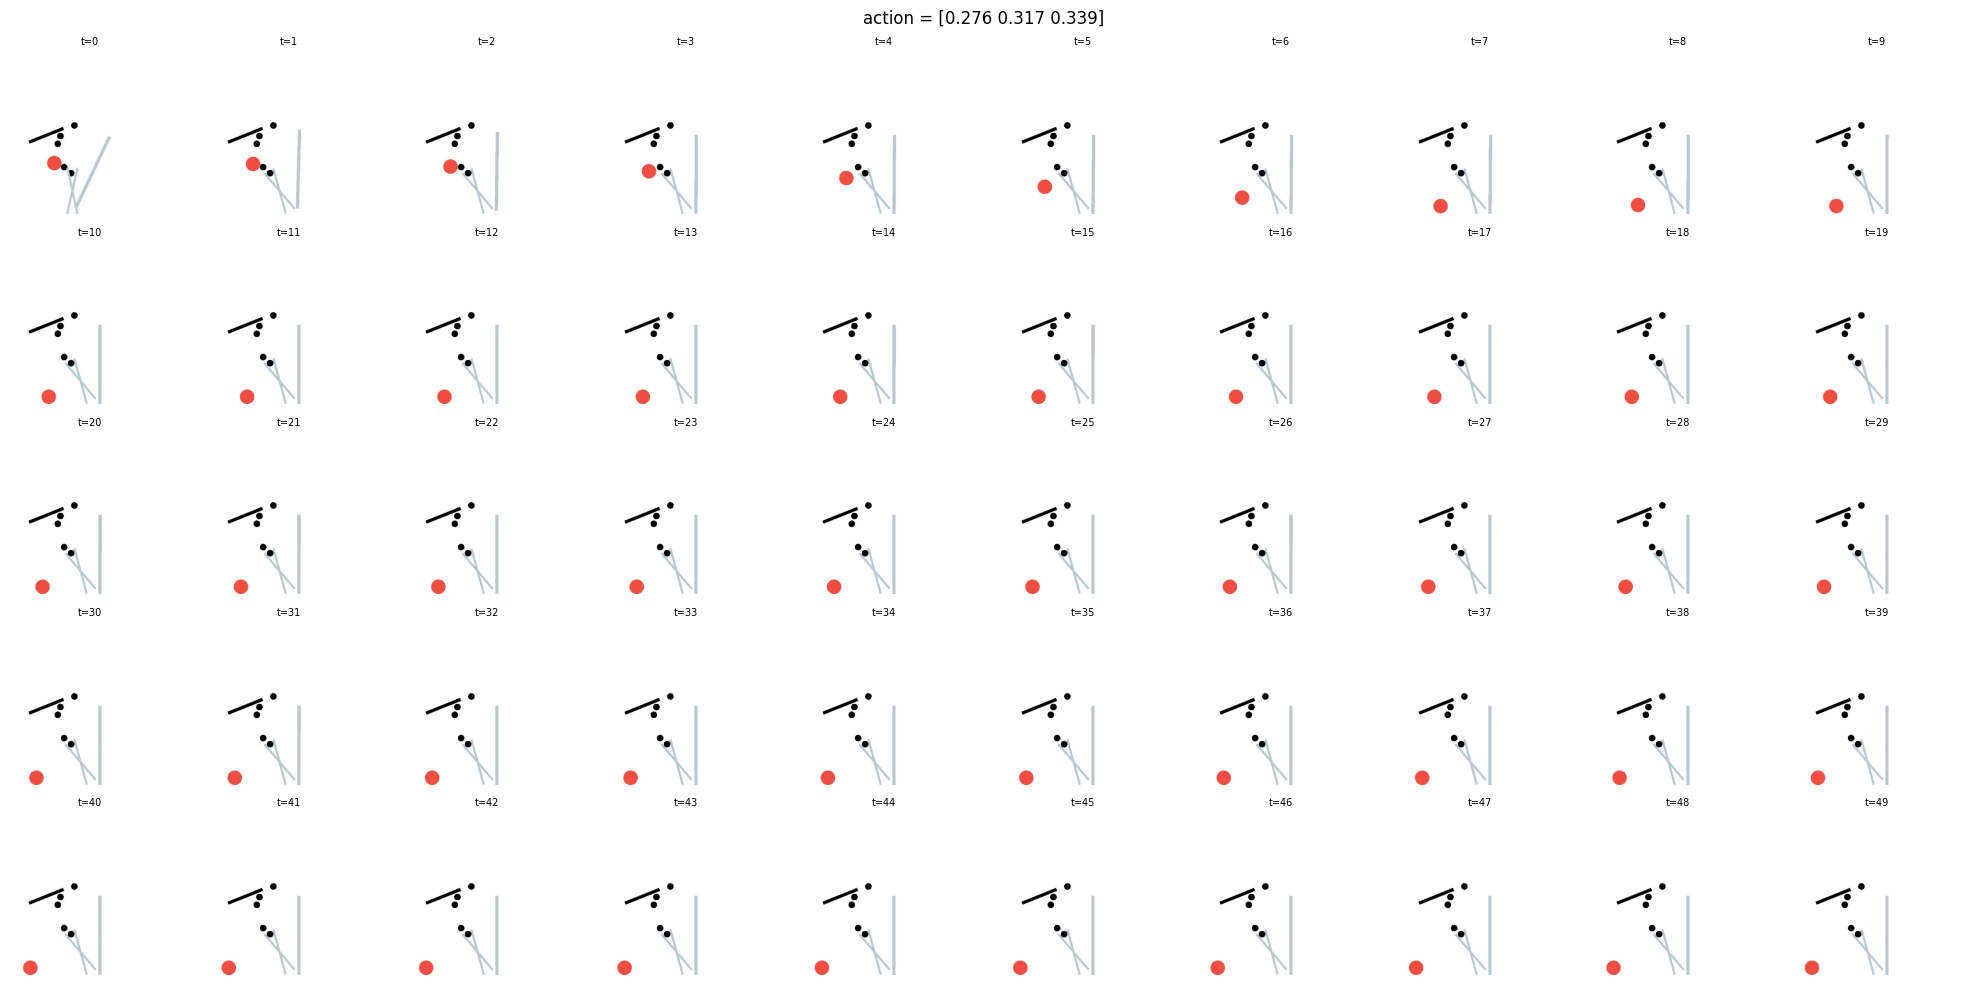

In [7]:
import h5py, io, numpy as np, decord
import matplotlib.pyplot as plt

f = h5py.File('/home/datasets/combinatorial_template_30:34.hdf5', 'r')
# shards are keyed like '10030:000' (not '00000'); each holds 1000 clips
shards = sorted(f['video_streams'].keys())

def load_clip(idx):
    s, r = divmod(idx, 1000)
    k = shards[s]
    mp4 = f[f'video_streams/{k}'][r].tobytes()
    frames = decord.VideoReader(io.BytesIO(mp4))[:].asnumpy()   # (50, 512, 512, 3)
    action = f[f'action_streams/{k}'][r]                         # (3,)
    objects = f[f'object_streams/{k}'][r]                        # (50, 9, 14)
    return frames, action, objects

def plot_frames(frames, action=None, ncols=10, size=2):
    T = len(frames)
    nrows = int(np.ceil(T / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size))
    for t, ax in enumerate(axes.flat):
        ax.axis('off')
        if t >= T:
            continue
        ax.imshow(frames[t])
        ax.set_title(f't={t}', fontsize=7)
    if action is not None:
        fig.suptitle('action = ' + np.array2string(action, precision=3))
    plt.tight_layout()
    plt.show()

frames, action, objects = load_clip(10)
plot_frames(frames, action)


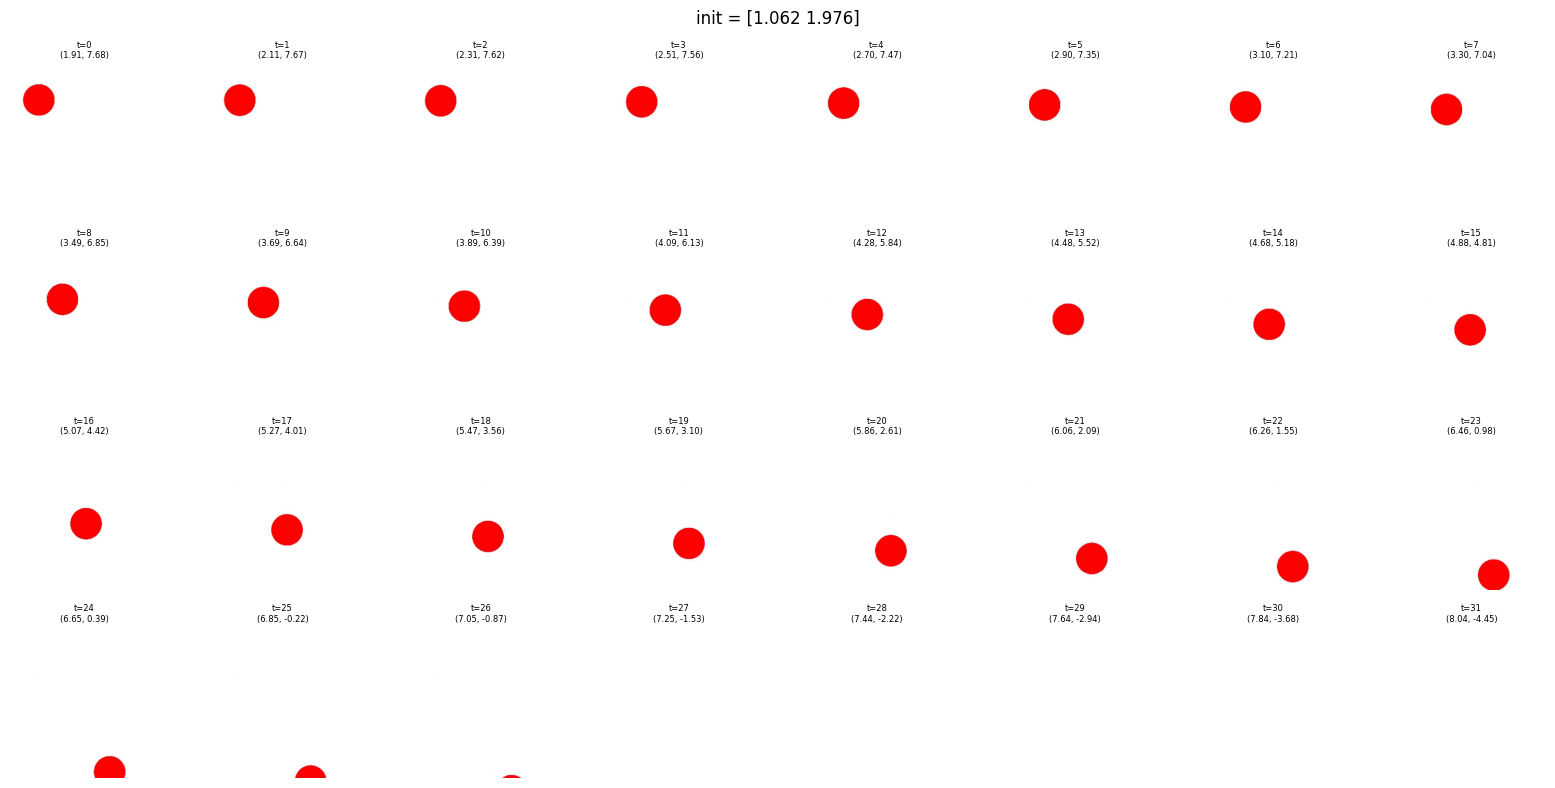

In [1]:
import h5py, io, numpy as np, decord
import matplotlib.pyplot as plt

f = h5py.File('/home/IDM/dataset/parabola_300K.hdf5', 'r')   # or parabola_eval.hdf5
# 300 shards of 1000 clips; offsets still work if shard sizes differ
shards = sorted(f['video_streams'].keys())
offsets = np.cumsum([0] + [len(f[f'video_streams/{k}']) for k in shards])
N = offsets[-1]

def load_clip(idx):
    s = np.searchsorted(offsets, idx, side='right') - 1
    k, r = shards[s], idx - offsets[s]
    mp4 = f[f'video_streams/{k}'][r].tobytes()
    frames = decord.VideoReader(io.BytesIO(mp4))[:].asnumpy()   # (32, 256, 256, 3)
    pos = f[f'position_streams/{k}'][r]                          # (32, xy): one ball
    init = f[f'init_streams/{k}'][r]                             # (2,)
    return frames, pos, init

def plot_frames(frames, pos=None, init=None, ncols=8, size=2):
    T = len(frames)
    nrows = int(np.ceil(T / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size))
    for t, ax in enumerate(axes.flat):
        ax.axis('off')
        if t >= T:
            continue
        ax.imshow(frames[t])
        title = f't={t}'
        if pos is not None:
            title += ''.join(f'\n({x:.2f}, {y:.2f})' for x, y in np.atleast_2d(pos[t]))  # 1 or 2 balls
        ax.set_title(title, fontsize=6)
    if init is not None:
        fig.suptitle('init = ' + np.array2string(init, precision=3))
    plt.tight_layout()
    plt.show()

frames, pos, init = load_clip(100)
plot_frames(frames, pos, init)


In [8]:
np.random.randint(low=100, high=2000)

576

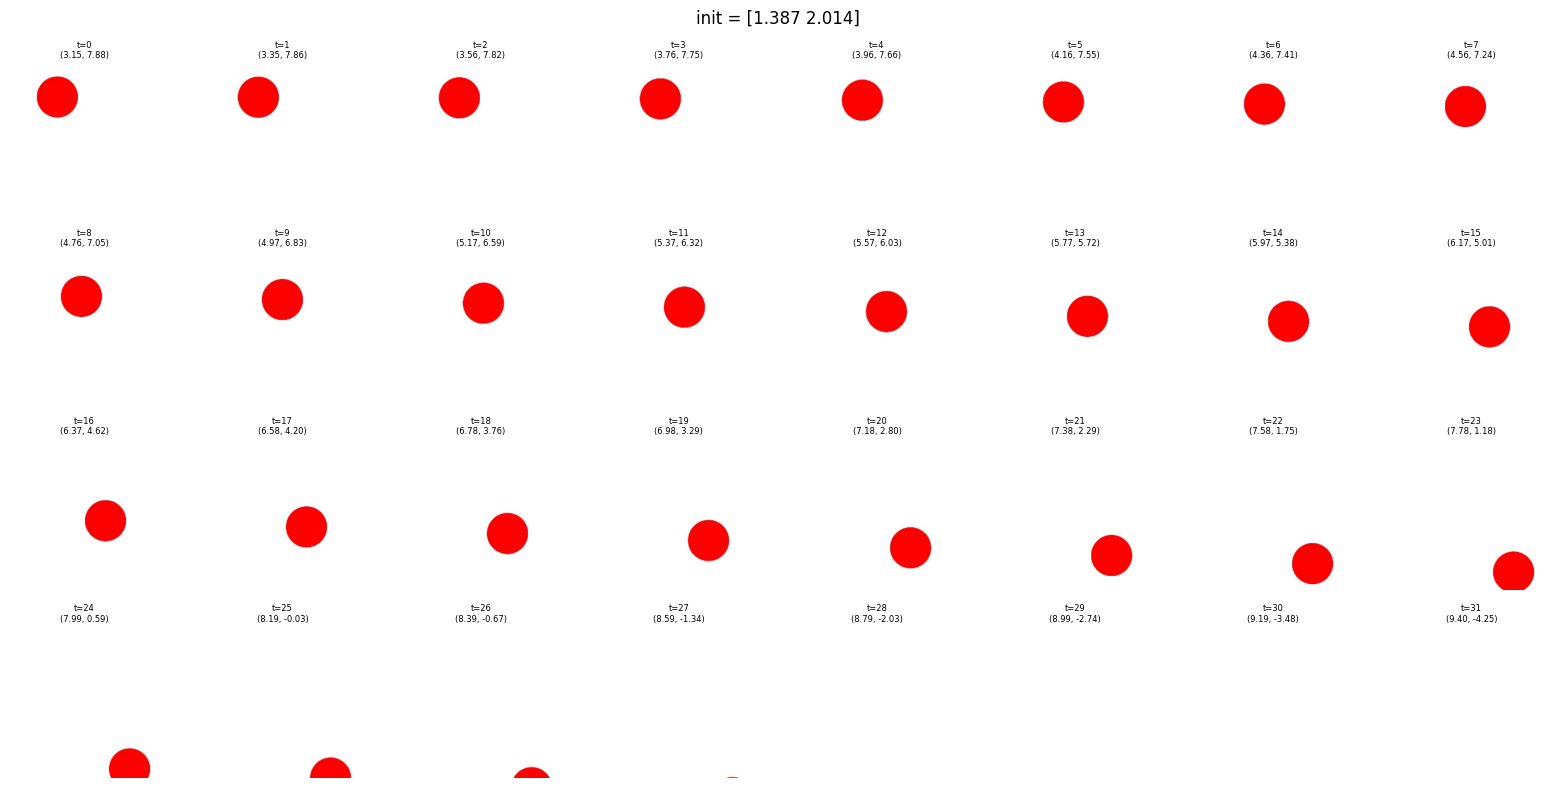

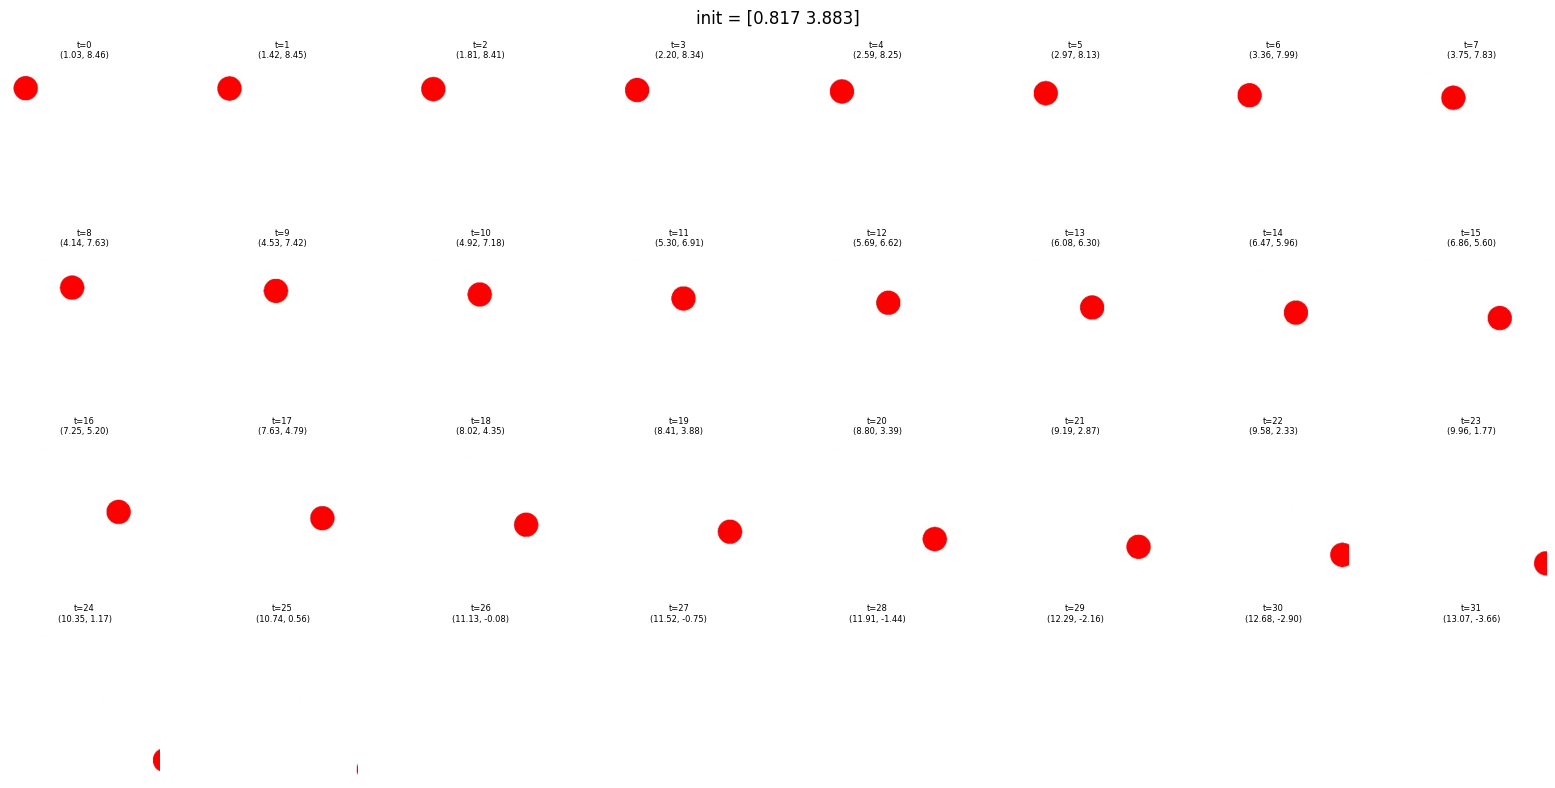

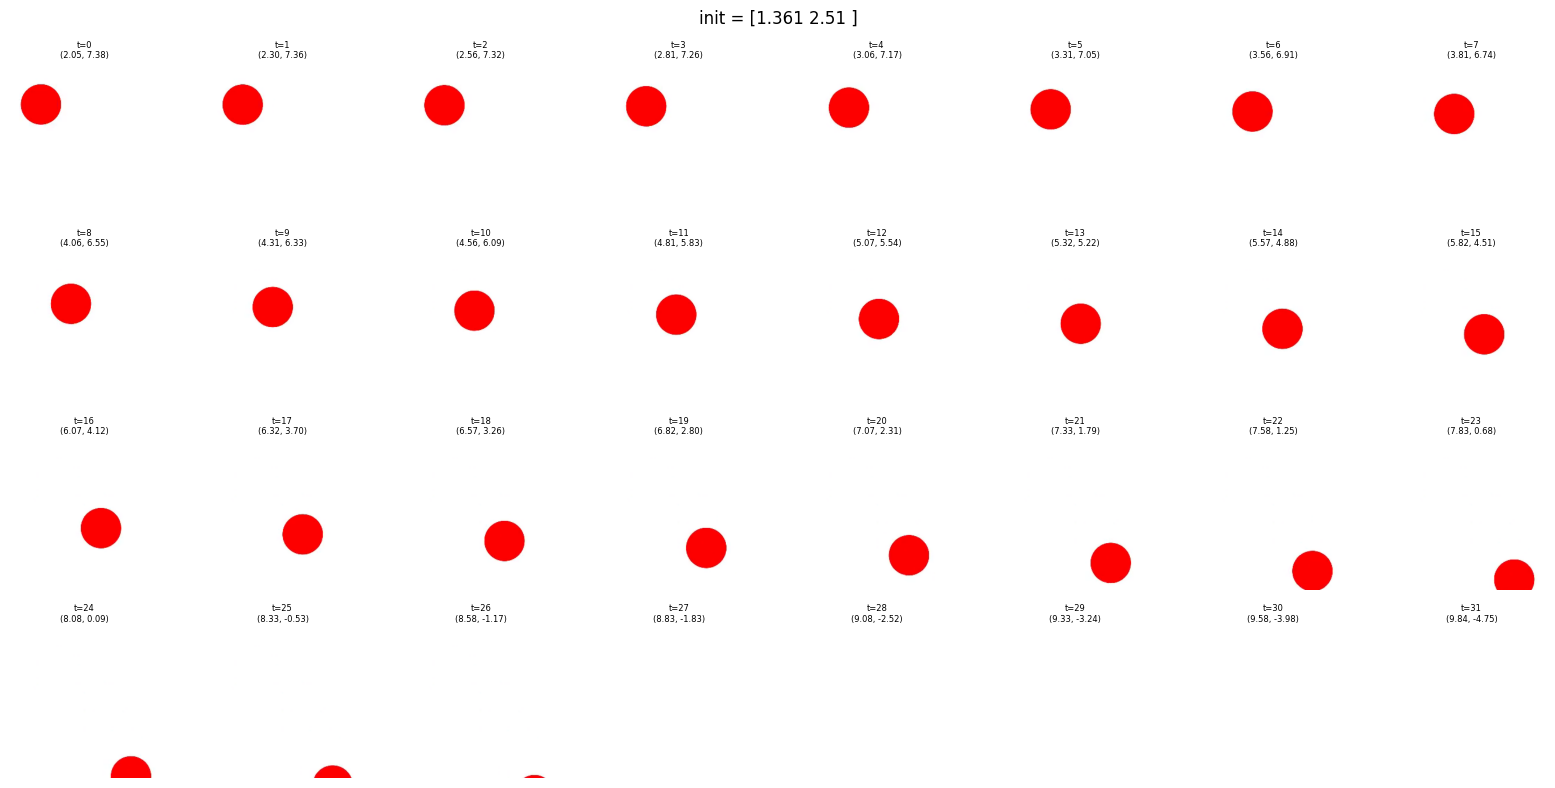

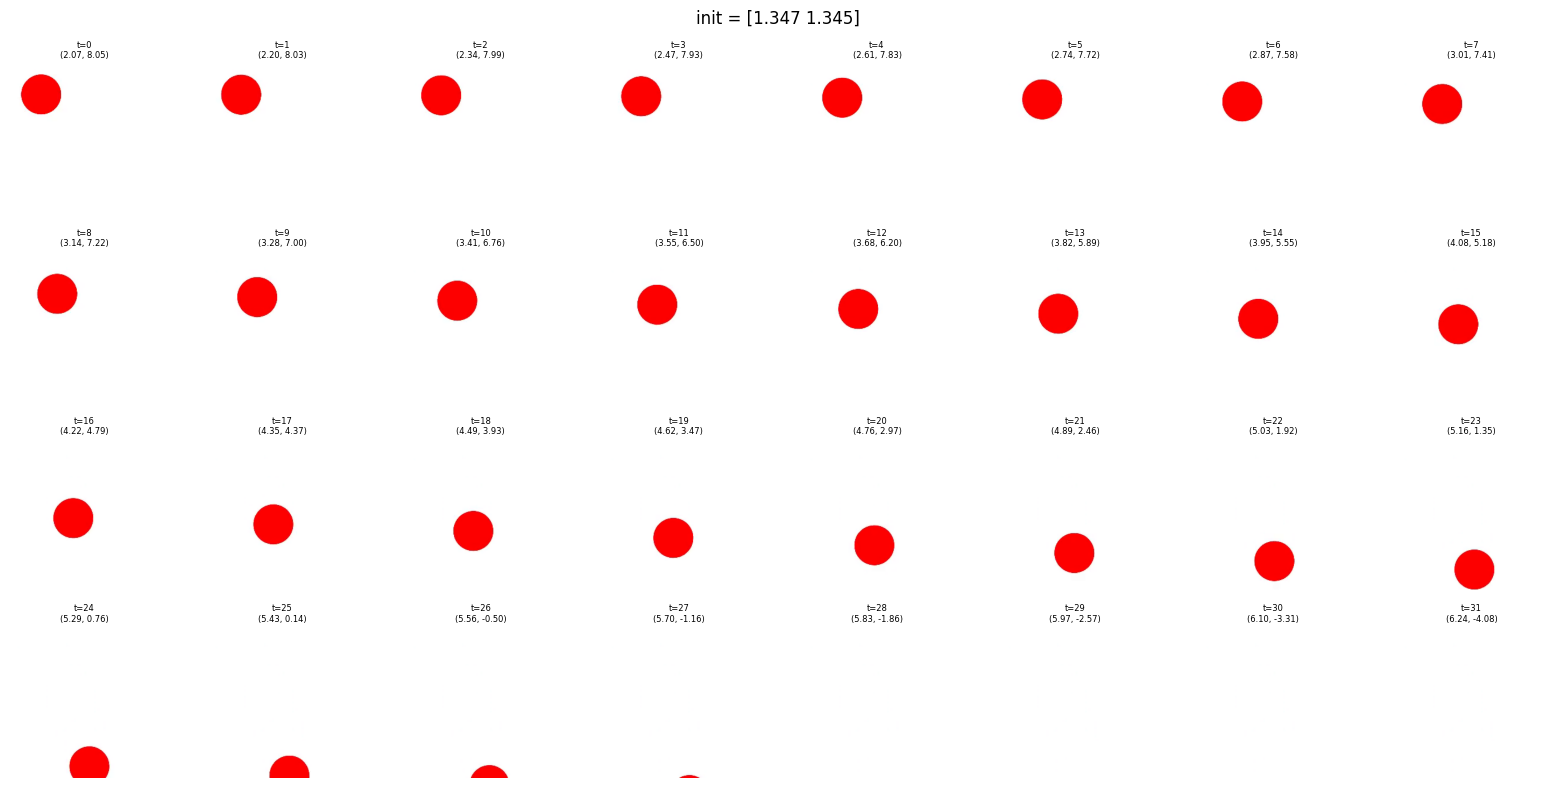

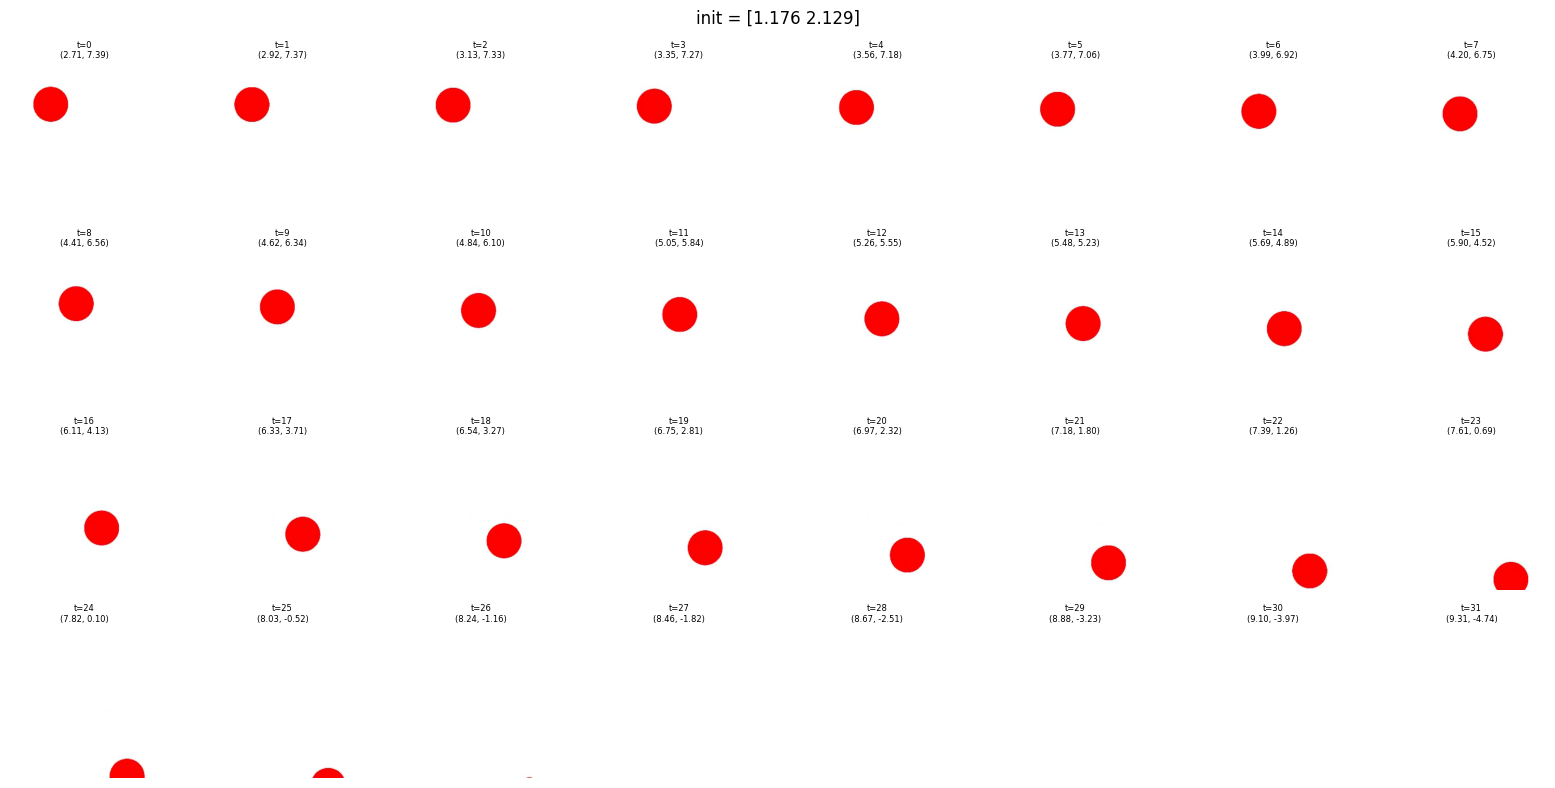

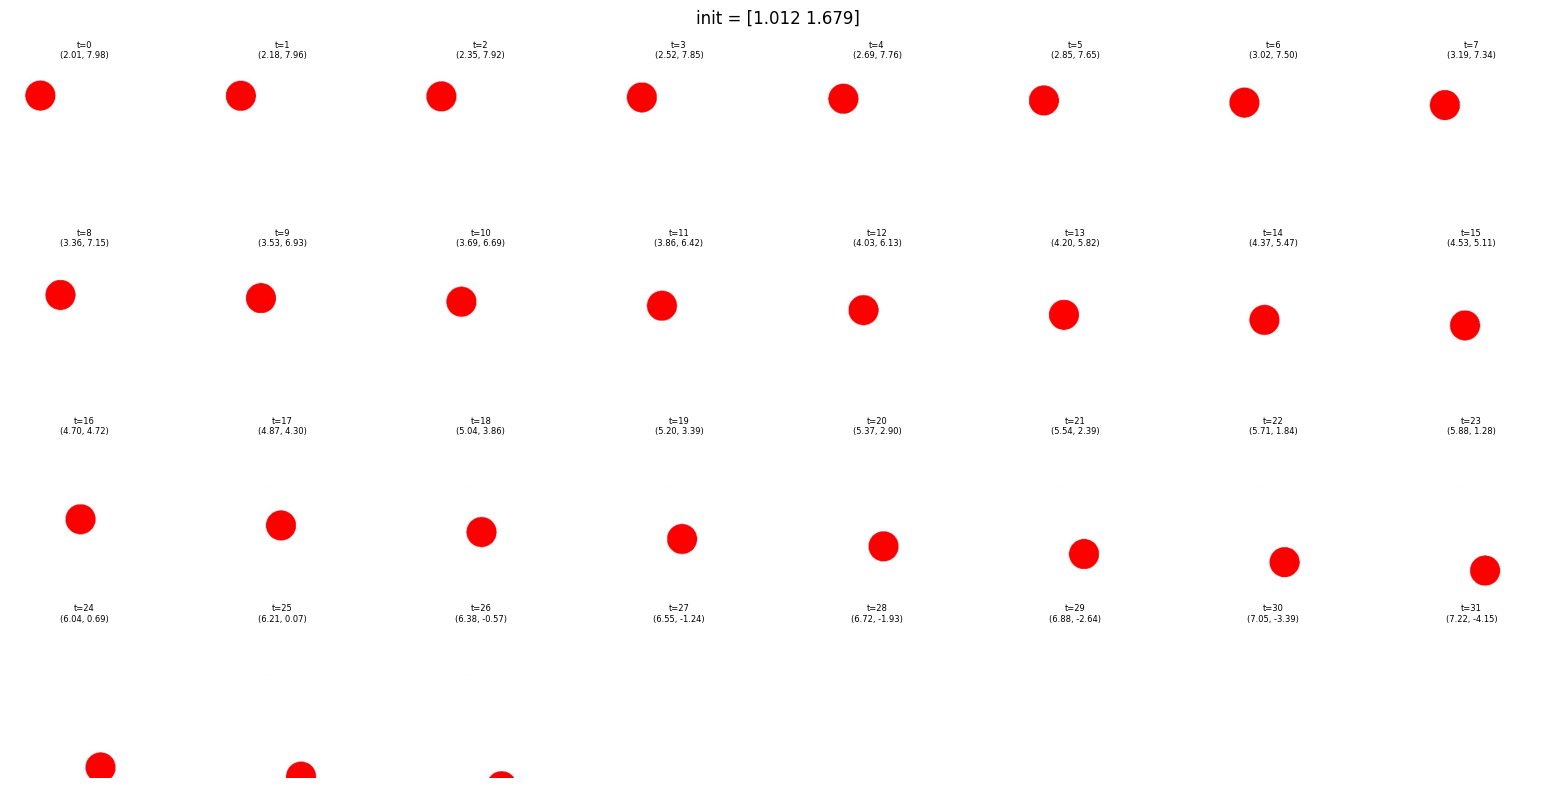

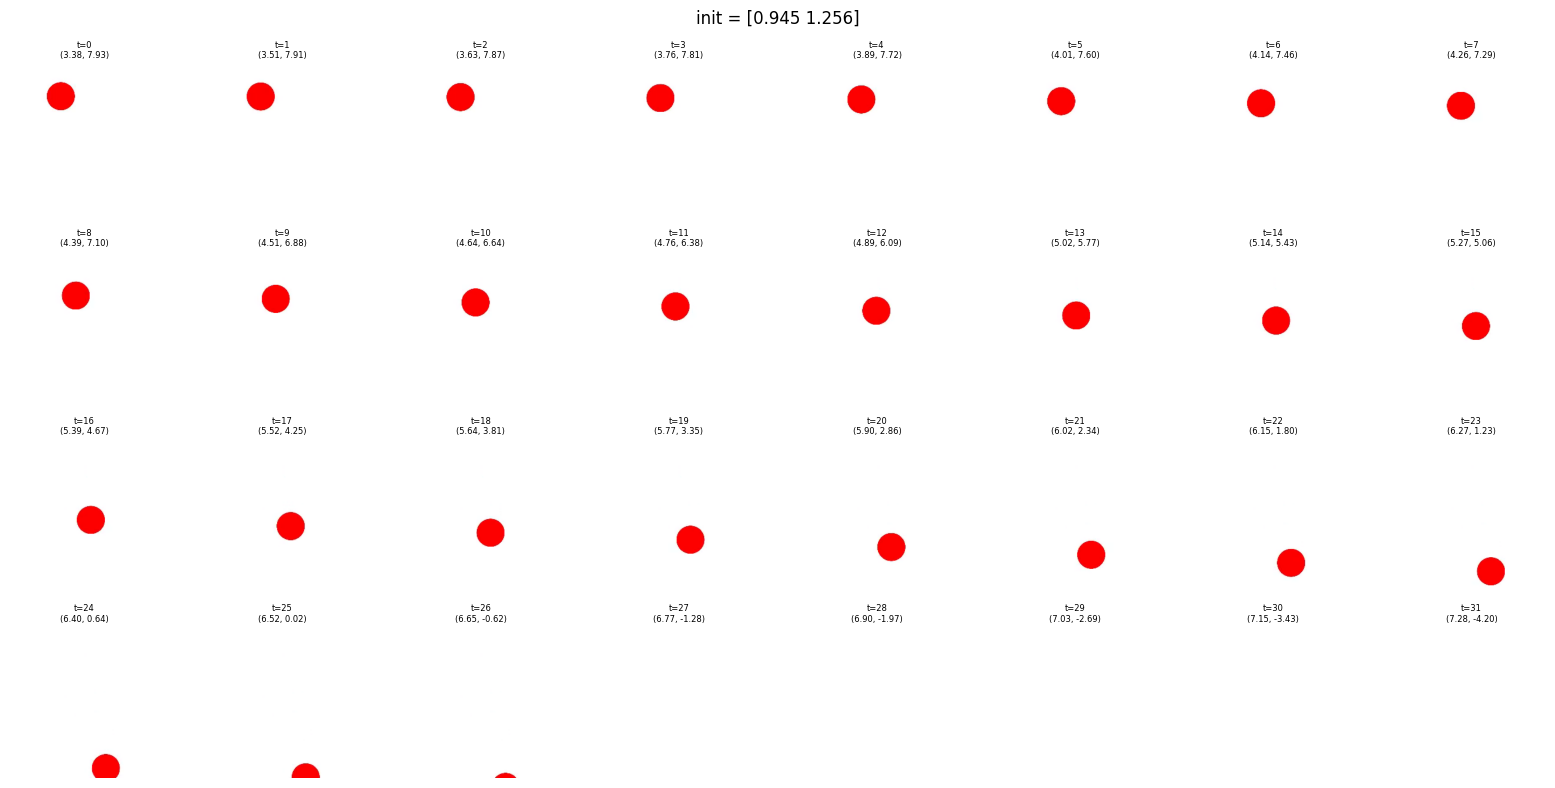

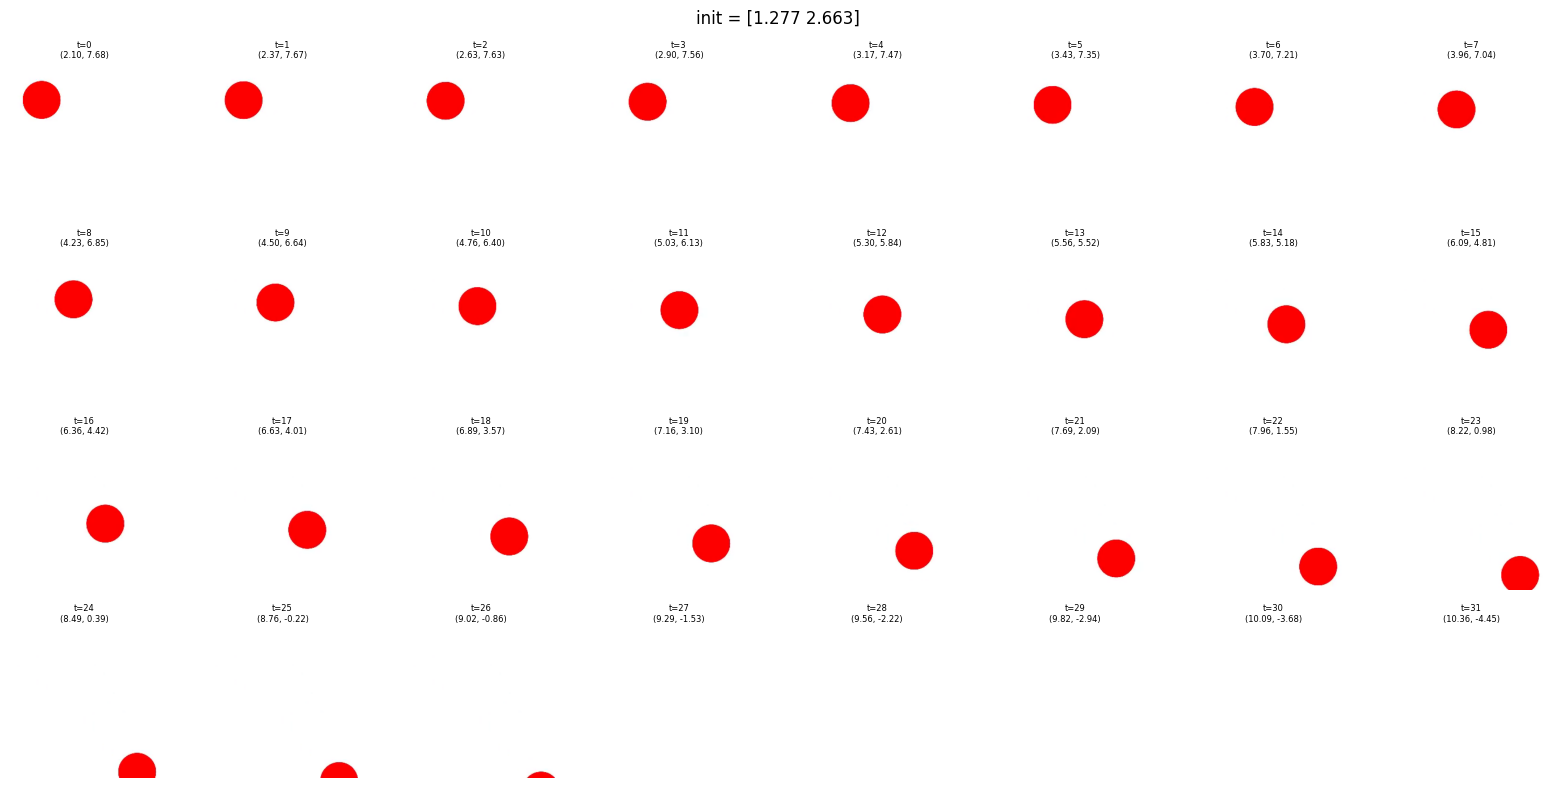

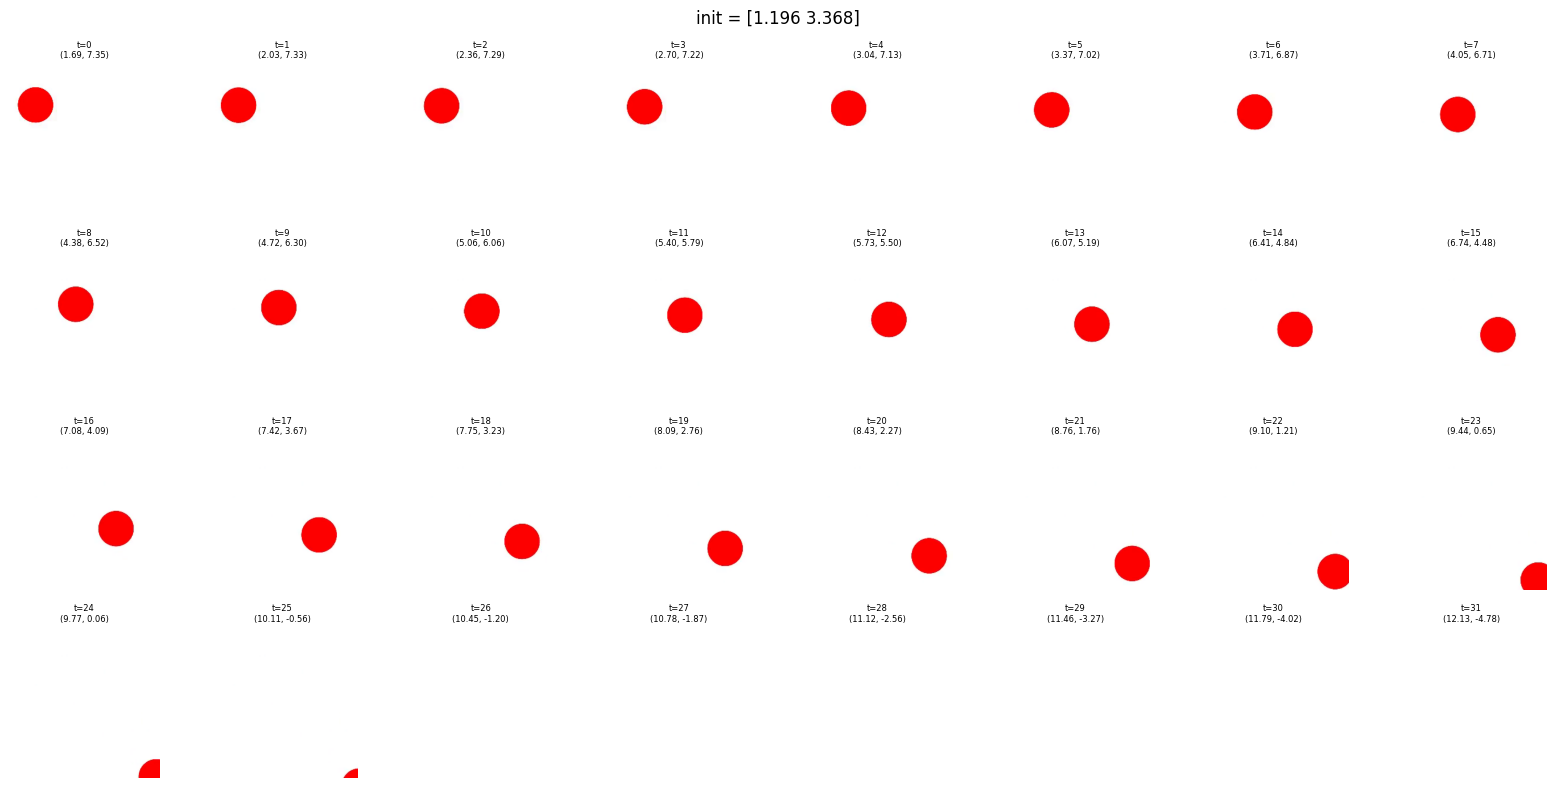

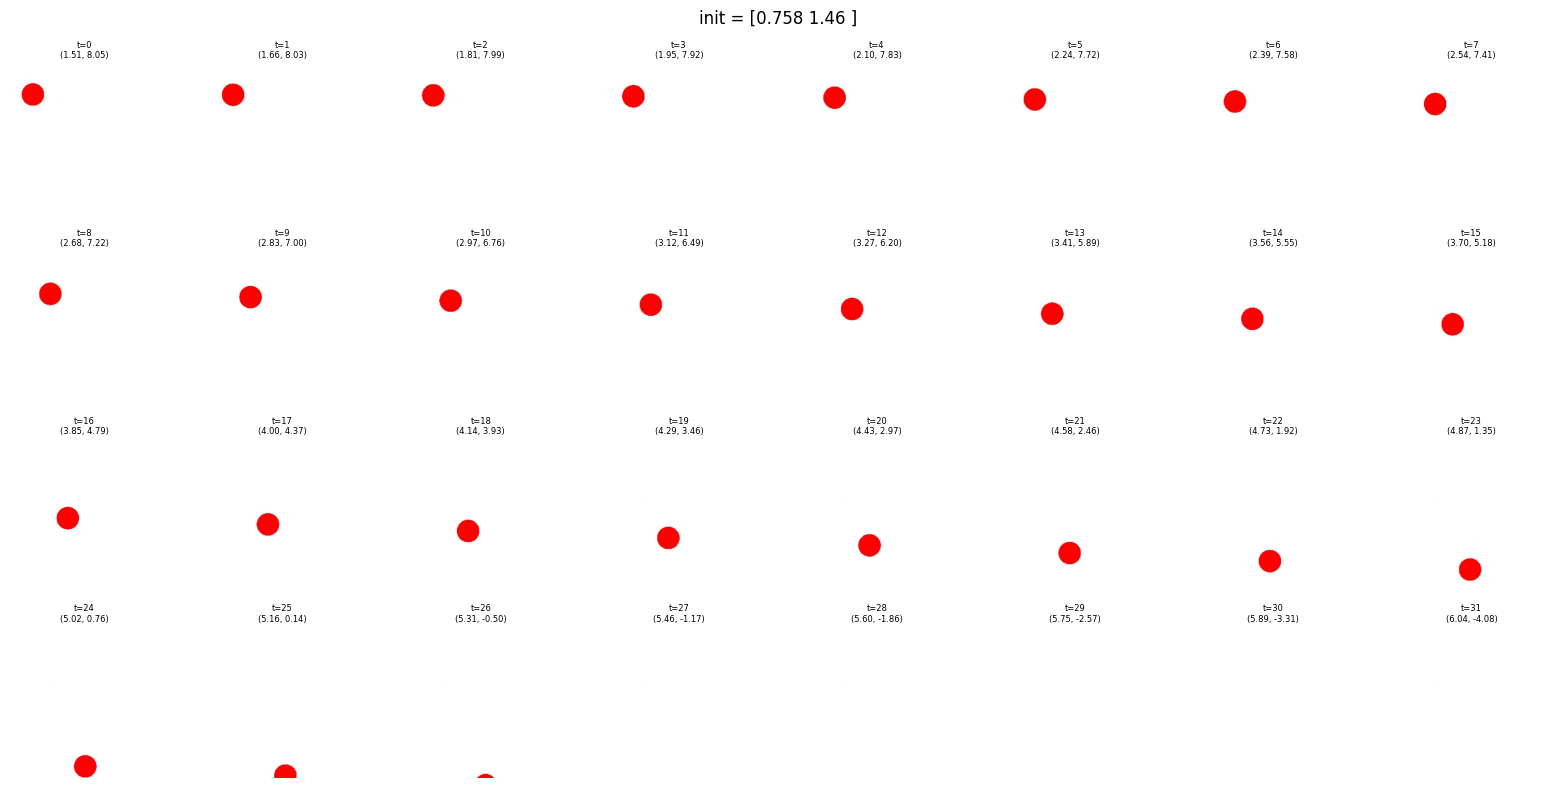

In [2]:
for i in range(10):
    idx = np.random.randint(low=100, high=2000)

    frames, pos, init = load_clip(idx)
    plot_frames(frames, pos, init)
